# 06 — Discount Impact on Profitability
Scatter plot of discount vs profit with trend line, plus average profit by discount bucket.


In [1]:
from pyhive import hive
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = sns.color_palette("muted")

def get_conn():
    return hive.connect(host="hive-server2", port=10000,
                        database="default", auth="NONE")

def fetch_df(cur, sql):
    cur.execute(sql)
    cols = [d[0].split(".")[-1] for d in cur.description]
    return pd.DataFrame(cur.fetchall(), columns=cols)

def fmt_usd(v):
    if abs(v) >= 1_000_000:
        return f"${v/1_000_000:.2f}M"
    if abs(v) >= 1_000:
        return f"${v/1_000:.1f}K"
    return f"${v:.0f}"

conn = get_conn()
cur  = conn.cursor()
print("Connected.")


Connected.


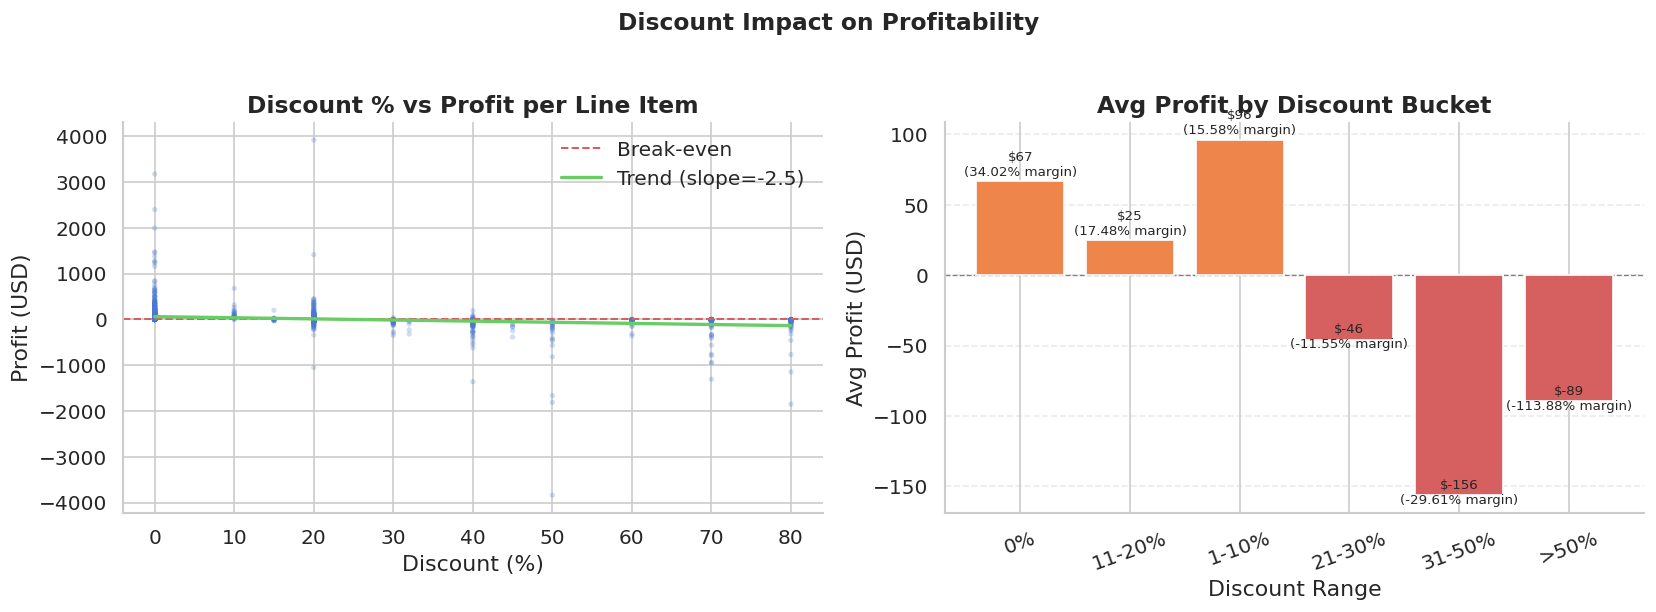

In [2]:
import numpy as np

# ── Discount vs Profitability ─────────────────────────────────────────────────
raw = fetch_df(cur, """
    SELECT ROUND(discount * 100, 0) AS discount_pct,
           ROUND(profit, 2)         AS profit
    FROM order_items
    LIMIT 3000
""")

# ── Bucketed summary ──────────────────────────────────────────────────────────
buckets = fetch_df(cur, """
    SELECT
        CASE
            WHEN discount = 0    THEN '0%'
            WHEN discount <= 0.1 THEN '1-10%'
            WHEN discount <= 0.2 THEN '11-20%'
            WHEN discount <= 0.3 THEN '21-30%'
            WHEN discount <= 0.5 THEN '31-50%'
            ELSE '>50%'
        END AS bucket,
        ROUND(AVG(profit), 2)            AS avg_profit,
        ROUND(AVG(profit/sales)*100, 2)  AS avg_margin_pct
    FROM order_items
    GROUP BY
        CASE
            WHEN discount = 0    THEN '0%'
            WHEN discount <= 0.1 THEN '1-10%'
            WHEN discount <= 0.2 THEN '11-20%'
            WHEN discount <= 0.3 THEN '21-30%'
            WHEN discount <= 0.5 THEN '31-50%'
            ELSE '>50%'
        END
    ORDER BY avg_margin_pct DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Discount Impact on Profitability",
             fontsize=14, fontweight="bold", y=1.02)

# Left: scatter + regression line
axes[0].scatter(raw["discount_pct"], raw["profit"],
                alpha=0.25, s=10, color=PALETTE[0], edgecolors="none")
axes[0].axhline(0, color=PALETTE[3], linewidth=1.2, linestyle="--",
                label="Break-even")
m, b = np.polyfit(raw["discount_pct"], raw["profit"], 1)
xs   = sorted(raw["discount_pct"].unique())
axes[0].plot(xs, [m*x + b for x in xs], color=PALETTE[2],
             linewidth=2, label=f"Trend (slope={m:.1f})")
axes[0].legend(frameon=False)
axes[0].set_title("Discount % vs Profit per Line Item")
axes[0].set_xlabel("Discount (%)")
axes[0].set_ylabel("Profit (USD)")

# Right: bucket avg profit bars
bucket_colors = [PALETTE[1] if v >= 0 else PALETTE[3]
                 for v in buckets["avg_profit"]]
bar2 = axes[1].bar(buckets["bucket"], buckets["avg_profit"],
                   color=bucket_colors, edgecolor="white", zorder=3)
axes[1].axhline(0, color="grey", linewidth=0.8, linestyle="--")
for bar, mg in zip(bar2, buckets["avg_margin_pct"]):
    h      = bar.get_height()
    offset = 2 if h >= 0 else -8
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 h + offset,
                 f"{fmt_usd(h)}\n({mg}% margin)",
                 ha="center", va="bottom", fontsize=8)

axes[1].set_title("Avg Profit by Discount Bucket")
axes[1].set_xlabel("Discount Range")
axes[1].set_ylabel("Avg Profit (USD)")
plt.xticks(rotation=20)
axes[1].grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()


In [3]:
cur.close()
conn.close()
print("Done.")


Done.
